<a href="https://colab.research.google.com/github/iyadgantengg120-oss/machine-learning/blob/main/ml_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Jumlah data train:", train.shape)
print("Jumlah data test:", test.shape)

Jumlah data train: (7352, 563)
Jumlah data test: (2947, 563)


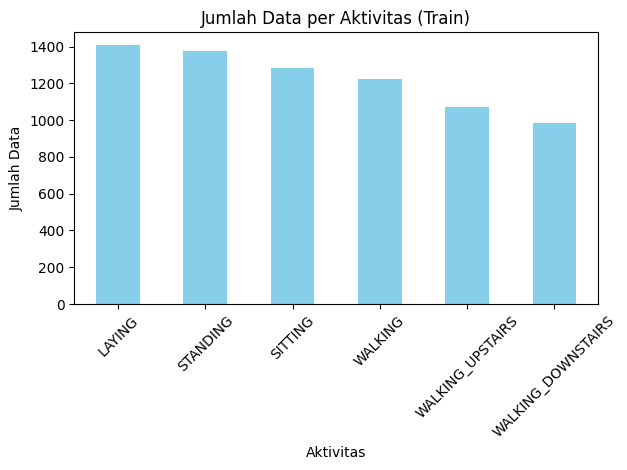

In [ ]:
import matplotlib.pyplot as plt

train['Activity'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Jumlah Data per Aktivitas (Train)')
plt.xlabel('Aktivitas')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Pisahkan fitur (X) dan target/label (y)
X_train = train.drop(['Activity', 'subject'], axis=1)
y_train = train['Activity']

X_test = test.drop(['Activity', 'subject'], axis=1)
y_test = test['Activity']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model selesai dilatih!")

Model selesai dilatih!


In [ ]:
print(X_train.shape)

(7352, 561)


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi model: {akurasi*100:.2f}%")

Akurasi model: 92.67%


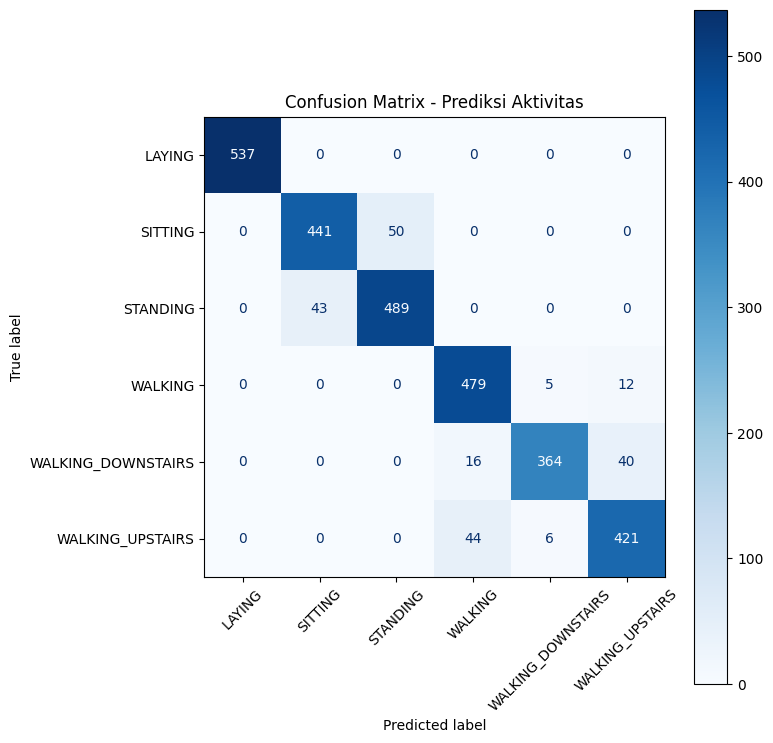

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Prediksi Aktivitas')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.89      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Model default (tanpa tuning)
start = time.time()
model_default = RandomForestClassifier(random_state=42)
model_default.fit(X_train, y_train)
waktu_default = time.time() - start

pred_default = model_default.predict(X_test)
akurasi_default = accuracy_score(y_test, pred_default)

print(f"[SEBELUM TUNING]")
print(f"Akurasi: {akurasi_default*100:.2f}%")
print(f"Waktu training: {waktu_default:.2f} detik")
print(f"Setelan default: n_estimators=100, max_depth=None")

[SEBELUM TUNING]
Akurasi: 92.67%
Waktu training: 29.84 detik
Setelan default: n_estimators=100, max_depth=None


In [ ]:
from sklearn.model_selection import GridSearchCV

# Kombinasi setelan yang mau dicoba
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,           # 3-fold cross validation
    scoring='accuracy',
    n_jobs=-1       # pakai semua core CPU biar lebih cepat
)

print("Sedang mencari setelan terbaik... (mungkin butuh beberapa menit)")
grid_search.fit(X_train, y_train)

print("\nSetelan terbaik ditemukan:")
print(grid_search.best_params_)

Sedang mencari setelan terbaik... (mungkin butuh beberapa menit)

Setelan terbaik ditemukan:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
start = time.time()
model_tuned = grid_search.best_estimator_
waktu_tuned = time.time() - start

pred_tuned = model_tuned.predict(X_test)
akurasi_tuned = accuracy_score(y_test, pred_tuned)

print(f"[SETELAH TUNING]")
print(f"Akurasi: {akurasi_tuned*100:.2f}%")
print(f"Setelan terbaik: {grid_search.best_params_}")

[SETELAH TUNING]
Akurasi: 92.23%
Setelan terbaik: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


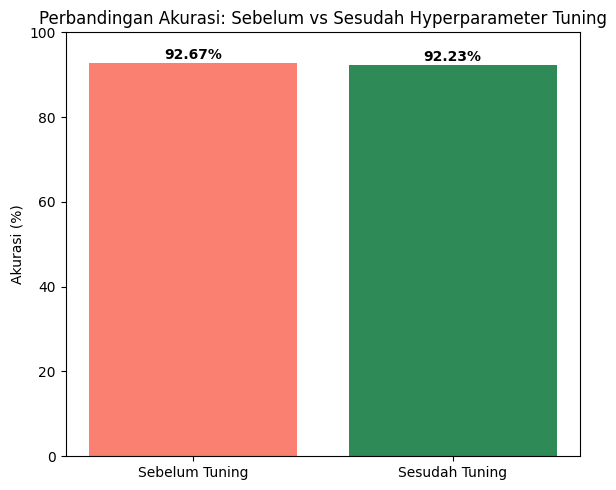


Kesimpulan:
Akurasi sebelum tuning : 92.67%
Akurasi sesudah tuning : 92.23%
Peningkatan            : -0.44 poin persen


In [ ]:
import matplotlib.pyplot as plt

labels = ['Sebelum Tuning', 'Sesudah Tuning']
akurasi = [akurasi_default*100, akurasi_tuned*100]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, akurasi, color=['salmon', 'seagreen'])
plt.title('Perbandingan Akurasi: Sebelum vs Sesudah Hyperparameter Tuning')
plt.ylabel('Akurasi (%)')
plt.ylim(0, 100)

# Tambahkan angka di atas bar
for bar, acc in zip(bars, akurasi):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKesimpulan:")
print(f"Akurasi sebelum tuning : {akurasi_default*100:.2f}%")
print(f"Akurasi sesudah tuning : {akurasi_tuned*100:.2f}%")
print(f"Peningkatan            : {(akurasi_tuned-akurasi_default)*100:.2f} poin persen")